In [201]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pickle

In [43]:
df = pd.read_csv("student_performance_dataset_1000.csv")
df

,Roll_No,Name,Gender,Semester,Branch,Attandance,Maths,DS,OS,DBMS,...,Age,City,Address,Pincode,State,Country,Participant,Mobile_Number,Email_ID,Game
0,RGPV0001,Zoya Dhillon,Female,6th,AIML,71,95,59,93,100,...,19,Surat,"House No. 677, Vesu, Surat",986260,Gujarat,India,No,3166482779,cbajaj@yahoo.com,Badminton
1,RGPV0002,Jayesh Sheth,Male,6th,AIDS,70,78,95,85,49,...,21,Mangalore,"House No. 535, Kadri, Mangalore",465573,Karnataka,India,Yes,6405753724,vbasu@gmail.com,Football
2,RGPV0003,Drishya Soman,Male,6th,CSIT,92,71,94,59,72,...,21,Pune,"House No. 895, Viman Nagar, Pune",764015,Maharashtra,India,Yes,9407411782,samibiju@gmail.com,Kabaddi
3,RGPV0004,Divij Kannan,Male,6th,CSE,75,67,99,41,74,...,19,Surat,"House No. 19, Vesu, Surat",423055,Gujarat,India,Yes,8067153468,ikrishnamurthy@dash.biz,NaN
4,RGPV0005,Anay Sen,Female,6th,DS,80,97,51,90,88,...,21,Bengaluru,"House No. 943, Indiranagar, Bengaluru",918305,Karnataka,India,No,8502877217,hrishita52@yahoo.com,Cricket
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,RGPV1496,Trisha Goswami,Female,6th,CSIT,80,87,71,82,86,...,19,Muzaffarpur,"House No. 91, Aghoria Bazar, Muzaffarpur",199301,Bihar,India,Yes,7473586831,manneyuvraj@hayre.biz,Badminton
1496,RGPV1497,Emir Uppal,Female,6th,DS,74,92,53,86,74,...,20,Patna,"House No. 624, Boring Road, Patna",859934,Bihar,India,No,9498203987,battauthkarsh@yahoo.com,Cricket
1497,RGPV1498,Zain Anne,Male,6th,CSE,72,52,50,82,59,...,19,Muzaffarpur,"House No. 260, Aghoria Bazar, Muzaffarpur",590537,Bihar,India,No,4485923215,korpalhimmat@sood-sehgal.com,Badminton
1498,RGPV1499,Sara Bansal,Male,6th,DS,78,94,45,64,82,...,20,Bengaluru,"House No. 294, Jayanagar, Bengaluru",377729,Karnataka,India,No,8352228043,dharmajankari@yahoo.com,Kabaddi


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Roll_No            1500 non-null   str    
 1   Name               1500 non-null   str    
 2   Gender             1500 non-null   str    
 3   Semester           1500 non-null   str    
 4   Branch             1500 non-null   str    
 5   Attandance         1500 non-null   int64  
 6   Maths              1500 non-null   int64  
 7   DS                 1500 non-null   int64  
 8   OS                 1500 non-null   int64  
 9   DBMS               1500 non-null   int64  
 10  AI                 1500 non-null   int64  
 11  Study_houre        1500 non-null   int64  
 12  Final_Percentage   1500 non-null   float64
 13  Performance_Label  1500 non-null   str    
 14  Father_Name        1500 non-null   str    
 15  Mother_Name        1500 non-null   str    
 16  Blood_Group        1500 non-null   

In [45]:
df["Game"].isnull().sum()

np.int64(263)

In [46]:
game = df["Game"].mode()[0]
df["Game"]=df["Game"].fillna(game)
df["Game"]=...

In [47]:
df.describe()

,Attandance,Maths,DS,OS,DBMS,AI,Study_houre,Final_Percentage,Age,Pincode,Mobile_Number
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1.500000e+03
mean,79.922000,70.612667,69.925333,70.012667,70.534667,70.470000,5.520667,70.311867,19.864000,499887.242667,5.069710e+09
std,11.707745,17.608521,17.629453,17.849171,17.653004,17.619385,0.841850,7.893189,0.781821,285308.533322,2.889339e+09
min,60.000000,40.000000,20.000000,40.000000,40.000000,40.000000,3.000000,46.600000,19.000000,6.000000,8.841603e+06
25%,70.000000,55.000000,55.000000,55.000000,55.000000,55.000000,5.000000,64.800000,19.000000,256978.750000,2.593334e+09
50%,80.000000,71.000000,70.000000,69.000000,71.000000,71.000000,6.000000,70.200000,20.000000,499252.500000,5.007902e+09
75%,90.000000,86.000000,85.000000,85.000000,86.000000,86.000000,6.000000,75.800000,20.000000,739801.000000,7.560828e+09
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,8.000000,92.800000,21.000000,999356.000000,9.999586e+09


In [48]:
def calculate_final_percentage(txt):
    subject_cols = ['Maths', 'DS', 'OS', 'DBMS', 'AI']
    txt['Total_Marks'] = txt[subject_cols].sum(axis=1)
    txt['Final_Percentage'] = (txt['Total_Marks'] / 500) * 100
    return txt

df = calculate_final_percentage(df)
df.head()

,Roll_No,Name,Gender,Semester,Branch,Attandance,Maths,DS,OS,DBMS,...,City,Address,Pincode,State,Country,Participant,Mobile_Number,Email_ID,Game,Total_Marks
0,RGPV0001,Zoya Dhillon,Female,6th,AIML,71,95,59,93,100,...,Surat,"House No. 677, Vesu, Surat",986260,Gujarat,India,No,3166482779,cbajaj@yahoo.com,Ellipsis,425
1,RGPV0002,Jayesh Sheth,Male,6th,AIDS,70,78,95,85,49,...,Mangalore,"House No. 535, Kadri, Mangalore",465573,Karnataka,India,Yes,6405753724,vbasu@gmail.com,Ellipsis,367
2,RGPV0003,Drishya Soman,Male,6th,CSIT,92,71,94,59,72,...,Pune,"House No. 895, Viman Nagar, Pune",764015,Maharashtra,India,Yes,9407411782,samibiju@gmail.com,Ellipsis,345
3,RGPV0004,Divij Kannan,Male,6th,CSE,75,67,99,41,74,...,Surat,"House No. 19, Vesu, Surat",423055,Gujarat,India,Yes,8067153468,ikrishnamurthy@dash.biz,Ellipsis,331
4,RGPV0005,Anay Sen,Female,6th,DS,80,97,51,90,88,...,Bengaluru,"House No. 943, Indiranagar, Bengaluru",918305,Karnataka,India,No,8502877217,hrishita52@yahoo.com,Ellipsis,422


C:\Users\sharn\AppData\Local\Temp\ipykernel_2360\3786615134.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=x,y=y,width=.5,palette="rainbow")


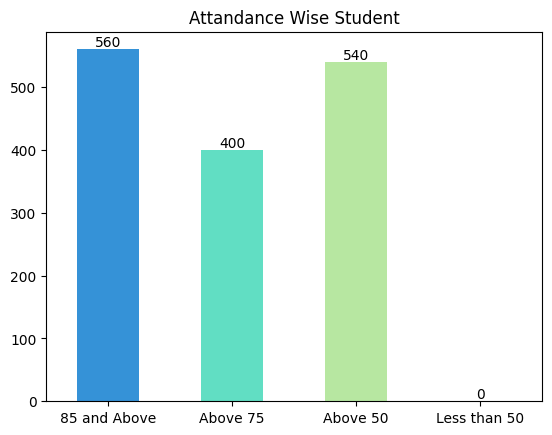

In [49]:

_gret85per = df[df["Attandance"]>=85]["Name"].count()
_gret75per = df[ (df["Attandance"]>=75) & (df["Attandance"]<85)] ["Name"].count()
_gret50per = df[ (df["Attandance"]>=50) & (df["Attandance"]<75)] ["Name"].count()
_less50per = df[ (df["Attandance"]<50)]["Name"].count()
x =["85 and Above","Above 75","Above 50","Less than 50"]
y =[_gret85per,_gret75per,_gret50per,_less50per]
ax = sns.barplot(x=x,y=y,width=.5,palette="rainbow")
plt.title("Attandance Wise Student")
def val (ax):
  for container in ax.containers:
      ax.bar_label(container)
val(ax)      

C:\Users\sharn\AppData\Local\Temp\ipykernel_2360\763336589.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=x,y=y,width=.5,palette="dark")


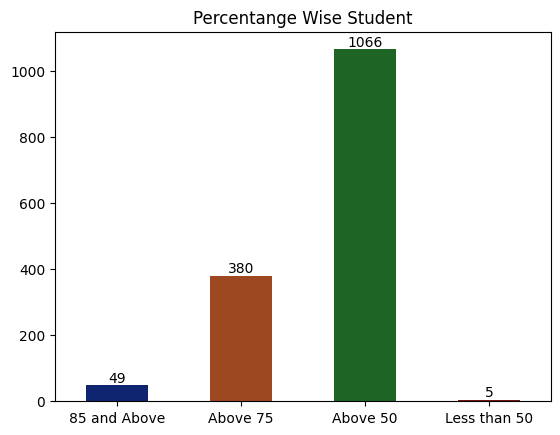

In [50]:

_gret85per = df[df["Final_Percentage"]>=85]["Name"].count()
_gret75per = df[ (df["Final_Percentage"]>=75) & (df["Final_Percentage"]<85)] ["Name"].count()
_gret50per = df[ (df["Final_Percentage"]>=50) & (df["Final_Percentage"]<75)] ["Name"].count()
_less50per = df[ (df["Final_Percentage"]<50)]["Name"].count()
x =["85 and Above","Above 75","Above 50","Less than 50"]
y =[_gret85per,_gret75per,_gret50per,_less50per]
ax = sns.barplot(x=x,y=y,width=.5,palette="dark")
plt.title("Percentange Wise Student")
val(ax)

C:\Users\sharn\AppData\Local\Temp\ipykernel_2360\3950361383.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=count.index,y=count.values,palette="brg",width=0.5)


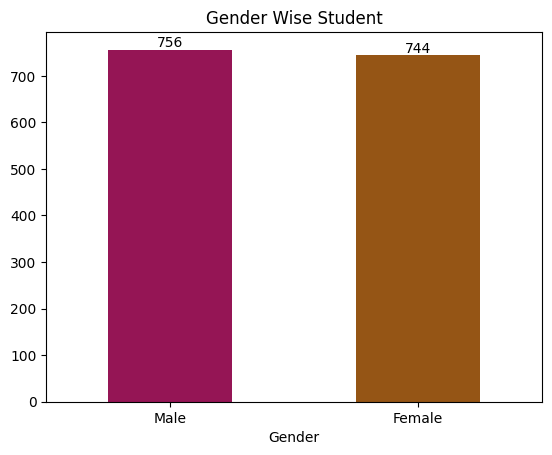

In [51]:
count = df["Gender"].value_counts()
ax = sns.barplot(x=count.index,y=count.values,palette="brg",width=0.5)
plt.title("Gender Wise Student")
val(ax)

Text(0.5, 1.0, 'Participant Wise Student')

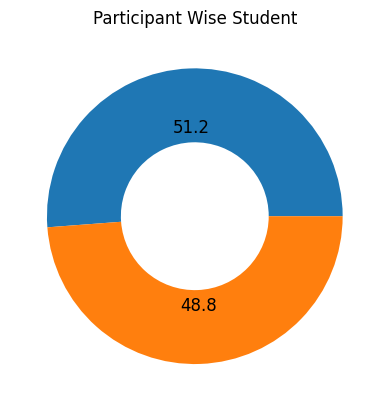

In [52]:
count1 = df["Participant"].value_counts()
value = [count1.values[0],count1.values[1]]
plt.pie(value, autopct="%0.1f",wedgeprops=dict(width=0.5),textprops={"fontsize":12})
plt.title("Participant Wise Student")



C:\Users\sharn\AppData\Local\Temp\ipykernel_2360\2740864464.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=count1.index,y=count1.values,palette="dark",width=0.5)


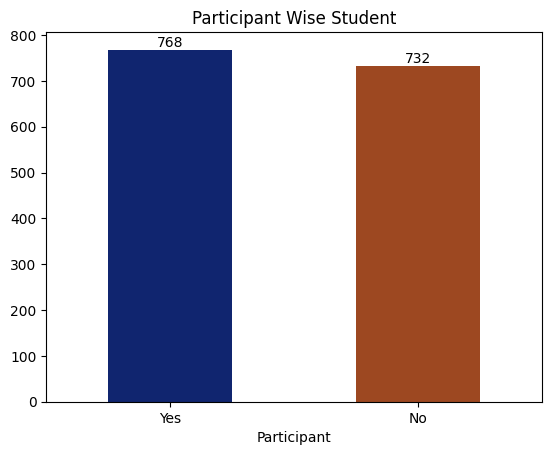

In [53]:
count1 = df["Participant"].value_counts()
ax = sns.barplot(x=count1.index,y=count1.values,palette="dark",width=0.5)
plt.title("Participant Wise Student")
val(ax)

In [54]:
df.drop("Total_Marks",axis=1,inplace=True)

C:\Users\sharn\AppData\Local\Temp\ipykernel_2360\3111463839.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(count2,palette="tab10")


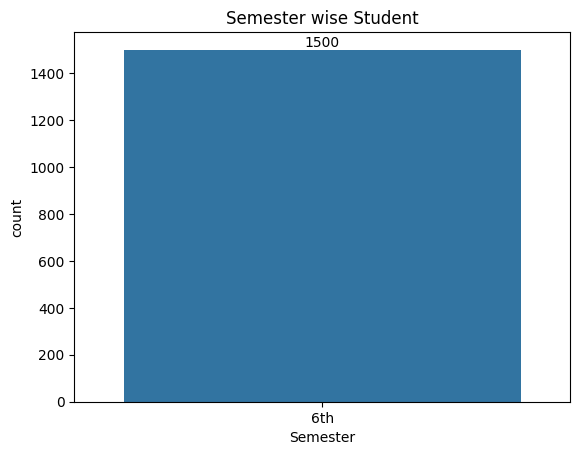

In [55]:
count2 = df["Semester"].value_counts()
ax = sns.barplot(count2,palette="tab10")
plt.title("Semester wise Student")
val(ax)      

C:\Users\sharn\AppData\Local\Temp\ipykernel_2360\3597272323.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(state,palette="tab10",width=0.5)


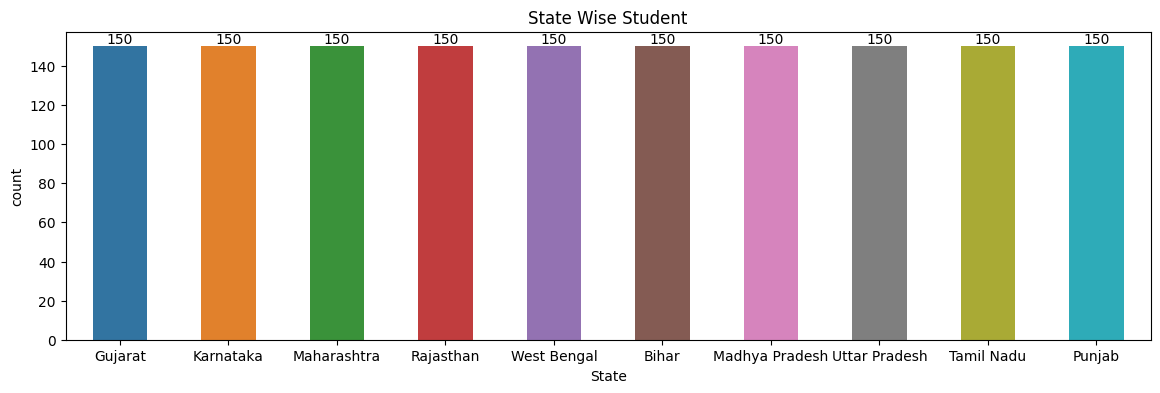

In [56]:
state = df["State"].value_counts()
plt.figure(figsize=(14,4))
ax = sns.barplot(state,palette="tab10",width=0.5)
plt.title("State Wise Student")
val(ax)

C:\Users\sharn\AppData\Local\Temp\ipykernel_2360\4018358084.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=x,y=y,width=.5,palette="tab10")
C:\Users\sharn\AppData\Local\Temp\ipykernel_2360\4018358084.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=x,y=y,width=.5,palette="tab10")
C:\Users\sharn\AppData\Local\Temp\ipykernel_2360\4018358084.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(count2,palette="tab10")
C:\Users\sharn\AppData\Local\Temp\ipykernel_2360\4018358084.py:30: FutureWarning: 

Passing `palette` 

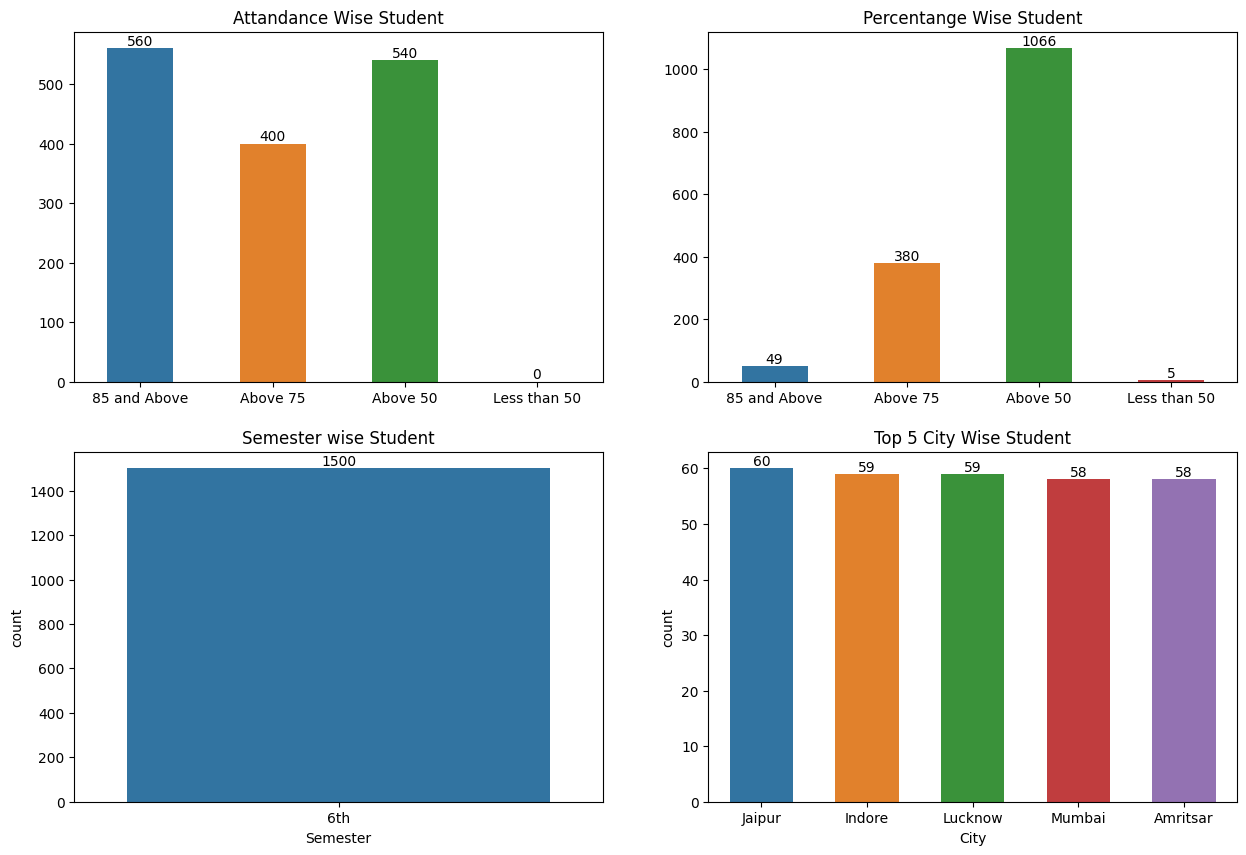

In [57]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
_gret85per = df[df["Attandance"]>=85]["Name"].count()
_gret75per = df[ (df["Attandance"]>=75) & (df["Attandance"]<85)] ["Name"].count()
_gret50per = df[ (df["Attandance"]>=50) & (df["Attandance"]<75)] ["Name"].count()
_less50per = df[ (df["Attandance"]<50)]["Name"].count()
x =["85 and Above","Above 75","Above 50","Less than 50"]
y =[_gret85per,_gret75per,_gret50per,_less50per]
ax = sns.barplot(x=x,y=y,width=.5,palette="tab10")
plt.title("Attandance Wise Student")
    
val(ax)
plt.subplot(2,2,2)
_gret85per = df[df["Final_Percentage"]>=85]["Name"].count()
_gret75per = df[ (df["Final_Percentage"]>=75) & (df["Final_Percentage"]<85)] ["Name"].count()
_gret50per = df[ (df["Final_Percentage"]>=50) & (df["Final_Percentage"]<75)] ["Name"].count()
_less50per = df[ (df["Final_Percentage"]<50)]["Name"].count()
x =["85 and Above","Above 75","Above 50","Less than 50"]
y =[_gret85per,_gret75per,_gret50per,_less50per]
ax = sns.barplot(x=x,y=y,width=.5,palette="tab10")
plt.title("Percentange Wise Student")
val(ax)
plt.subplot(2,2,3)
count2 = df["Semester"].value_counts()
ax = sns.barplot(count2,palette="tab10")
plt.title("Semester wise Student")
val(ax) 
plt.subplot(2,2,4)
top10citystudent = df.value_counts("City").sort_values(ascending=False).head(5)
ax = sns.barplot(top10citystudent,palette="tab10",width=0.6)
plt.title("Top 5 City Wise Student")
val(ax)

In [58]:
city = df.groupby("City")["Name"].value_counts()
city


City       Name          
Ahmedabad  Biju Mand         1
           Sumer Chacko      1
           Charvi Cherian    1
           Jayant Kaur       1
           Myra Magar        1
                            ..
Varanasi   Sana Kant         1
           Reyansh Sharaf    1
           Nirvi Raval       1
           Anya Borde        1
           Alia Mangal       1
Name: count, Length: 1500, dtype: int64

C:\Users\sharn\AppData\Local\Temp\ipykernel_2360\3690462411.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(top10citystudent,palette="tab10",width=0.6)


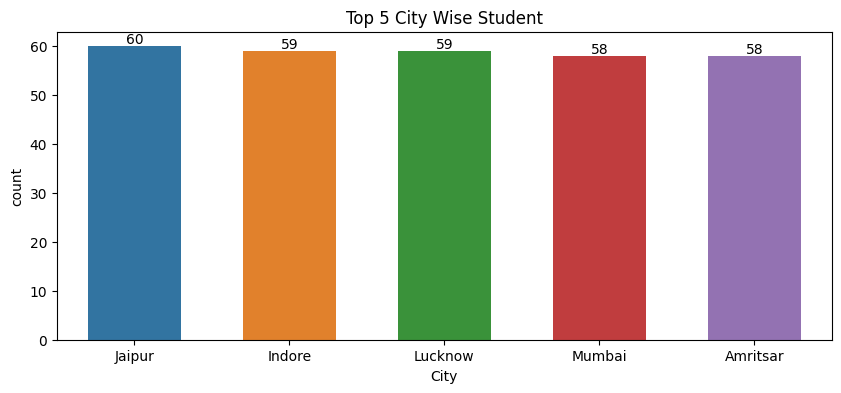

In [59]:
top10citystudent = df.value_counts("City").sort_values(ascending=False).head(5)
plt.figure(figsize=(10,4))
ax = sns.barplot(top10citystudent,palette="tab10",width=0.6)
plt.title("Top 5 City Wise Student")
val(ax)


C:\Users\sharn\AppData\Local\Temp\ipykernel_2360\964876622.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(branch,width=0.8,palette="tab10")


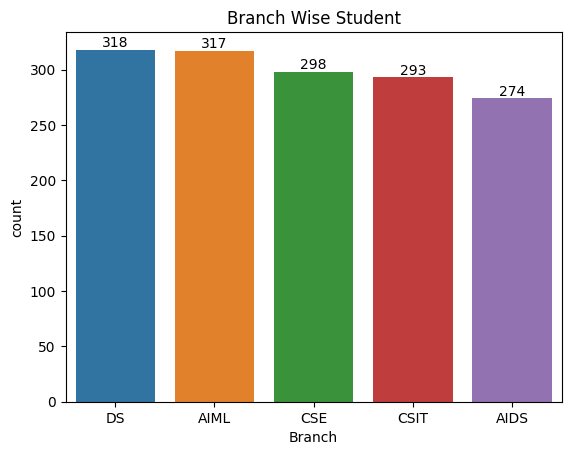

In [60]:
branch = df.value_counts("Branch")
ax = sns.barplot(branch,width=0.8,palette="tab10")
plt.title("Branch Wise Student")
val(ax)

In [61]:
df.head(2)

,Roll_No,Name,Gender,Semester,Branch,Attandance,Maths,DS,OS,DBMS,...,Age,City,Address,Pincode,State,Country,Participant,Mobile_Number,Email_ID,Game
0,RGPV0001,Zoya Dhillon,Female,6th,AIML,71,95,59,93,100,...,19,Surat,"House No. 677, Vesu, Surat",986260,Gujarat,India,No,3166482779,cbajaj@yahoo.com,Ellipsis
1,RGPV0002,Jayesh Sheth,Male,6th,AIDS,70,78,95,85,49,...,21,Mangalore,"House No. 535, Kadri, Mangalore",465573,Karnataka,India,Yes,6405753724,vbasu@gmail.com,Ellipsis


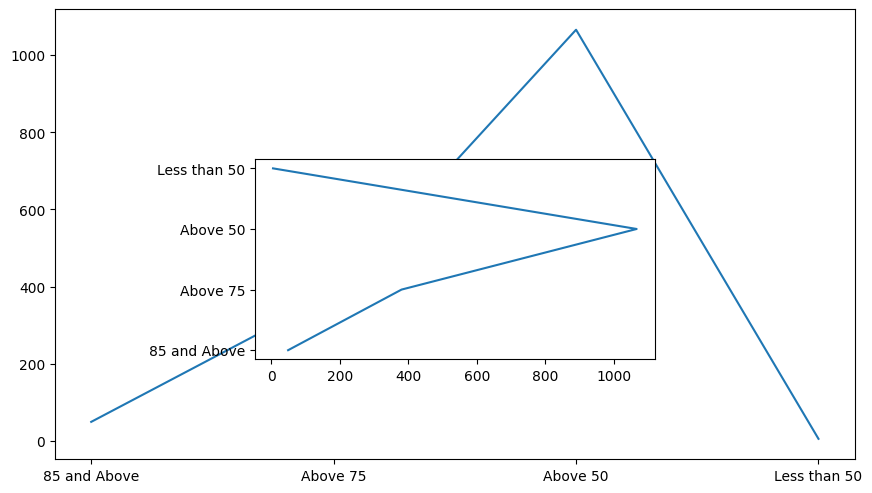

In [62]:
fig = plt.figure(figsize=(10,5),dpi=100)
axice1 = fig.add_axes([0.2,0.5,0.8,0.9])
axice1.plot(x,y)
axice2 = fig.add_axes([0.4,0.7,0.4,0.4])   # Its called Object_Oriented plotting
axice2.plot(y,x)

C:\Users\sharn\AppData\Local\Temp\ipykernel_2360\1222644733.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=count.index,y=count.values,palette="tab10",width=0.5)
C:\Users\sharn\AppData\Local\Temp\ipykernel_2360\1222644733.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=count1.index,y=count1.values,palette="tab10",width=0.5)
C:\Users\sharn\AppData\Local\Temp\ipykernel_2360\1222644733.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(branch,width=0.8,palette="tab10")
C:\Users\sharn\AppData\Local\Temp\ipykernel_236

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Gujarat'),
  Text(1, 0, 'Karnataka'),
  Text(2, 0, 'Maharashtra'),
  Text(3, 0, 'Rajasthan'),
  Text(4, 0, 'West Bengal'),
  Text(5, 0, 'Bihar'),
  Text(6, 0, 'Madhya Pradesh'),
  Text(7, 0, 'Uttar Pradesh'),
  Text(8, 0, 'Tamil Nadu'),
  Text(9, 0, 'Punjab')])

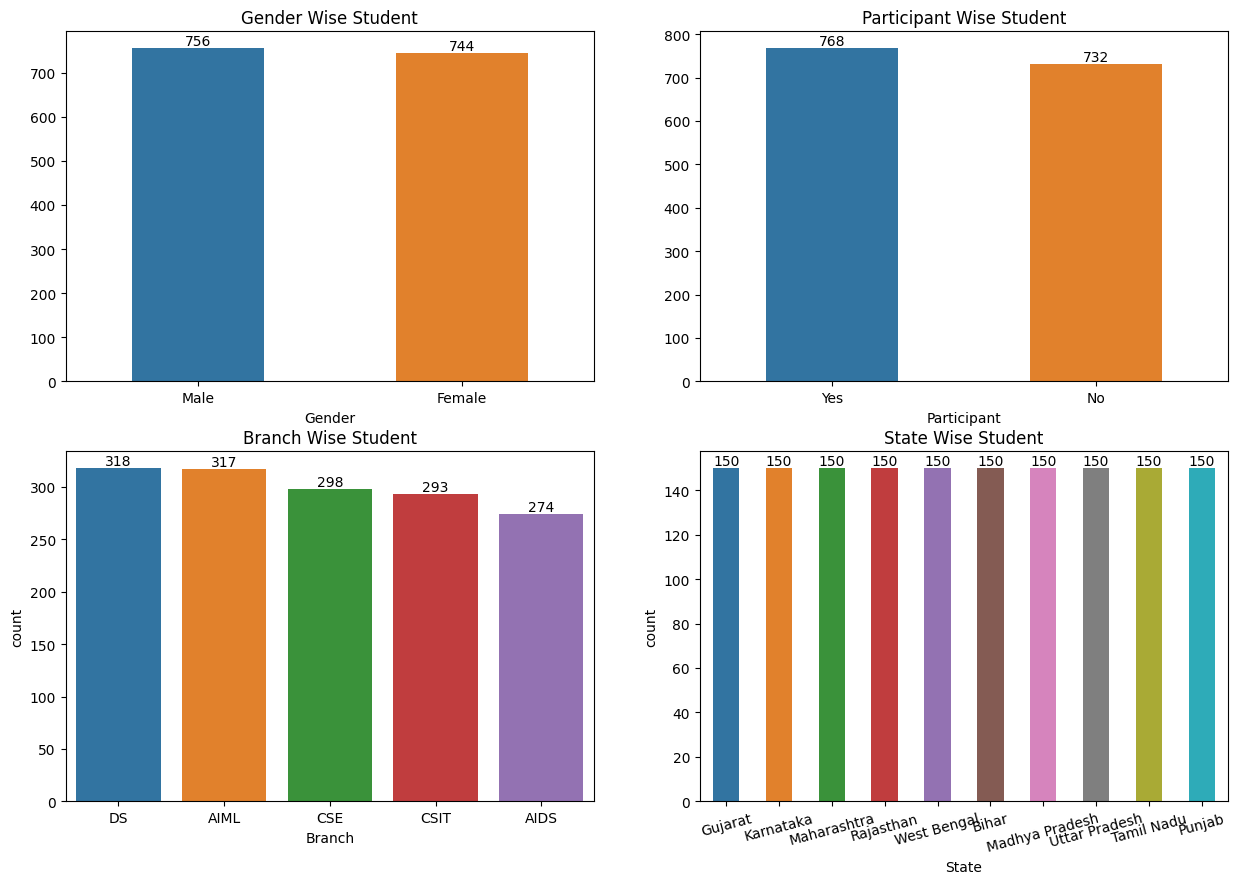

In [63]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
count = df["Gender"].value_counts()
ax = sns.barplot(x=count.index,y=count.values,palette="tab10",width=0.5)
plt.title("Gender Wise Student")
val(ax)
plt.subplot(2,2,2)
count1 = df["Participant"].value_counts()
ax = sns.barplot(x=count1.index,y=count1.values,palette="tab10",width=0.5)
plt.title("Participant Wise Student")
val(ax)
plt.subplot(2,2,3)
branch = df.value_counts("Branch")
ax = sns.barplot(branch,width=0.8,palette="tab10")
plt.title("Branch Wise Student")
val(ax)
plt.subplot(2,2,4)
state = df["State"].value_counts()
ax = sns.barplot(state,palette="tab10",width=0.5)
plt.title("State Wise Student")
val(ax)
plt.xticks(rotation =15)

<Axes: >

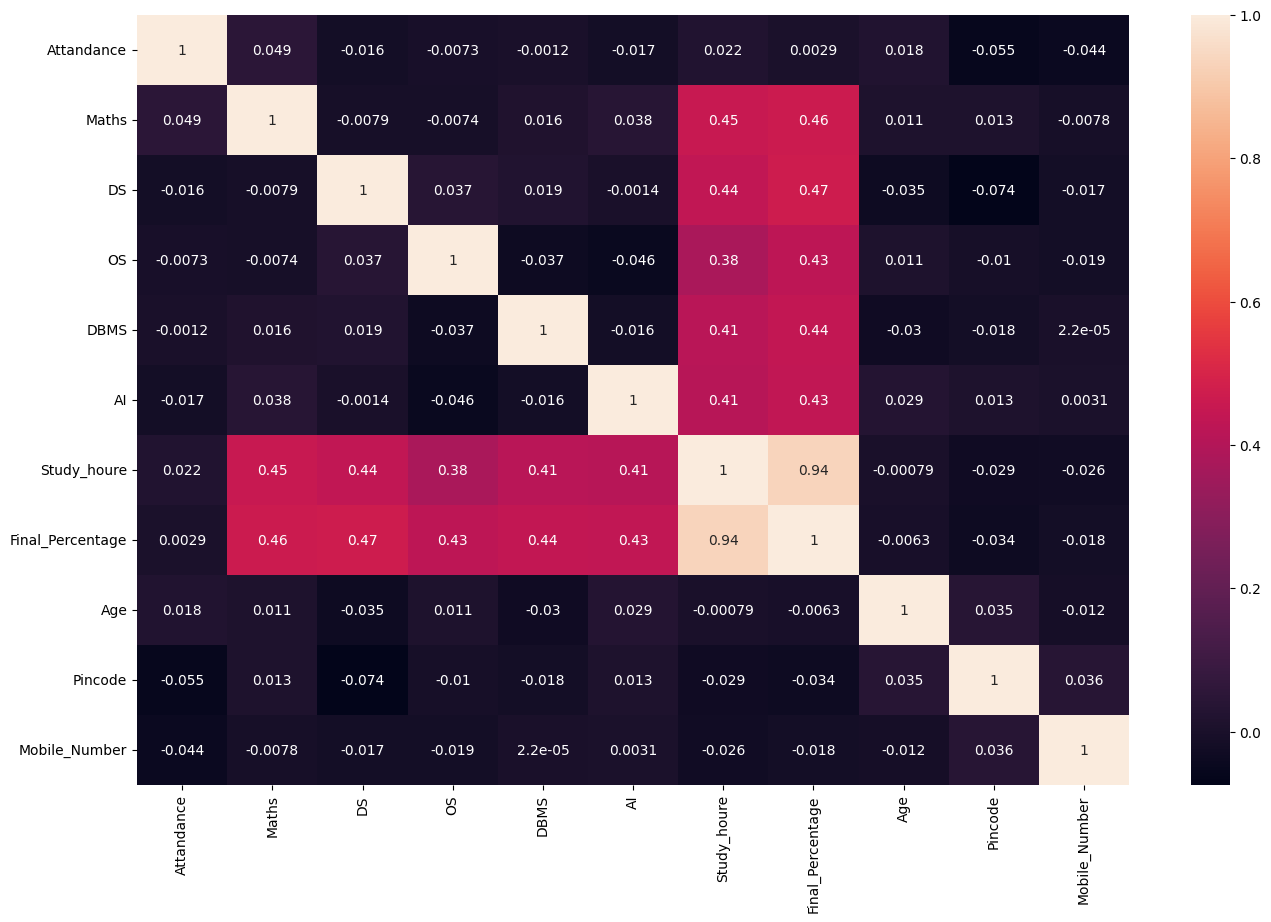

In [64]:
plt.figure(figsize=(16,10))
sns.heatmap(df.corr(numeric_only=True) ,annot=True)

In [65]:
df.columns

Index(['Roll_No', 'Name', 'Gender', 'Semester', 'Branch', 'Attandance',
       'Maths', 'DS', 'OS', 'DBMS', 'AI', 'Study_houre', 'Final_Percentage',
       'Performance_Label', 'Father_Name', 'Mother_Name', 'Blood_Group',
       'Date_of_Birth', 'Age', 'City', 'Address', 'Pincode', 'State',
       'Country', 'Participant', 'Mobile_Number', 'Email_ID', 'Game'],
      dtype='str')

<Axes: xlabel='Study_houre', ylabel='Final_Percentage'>

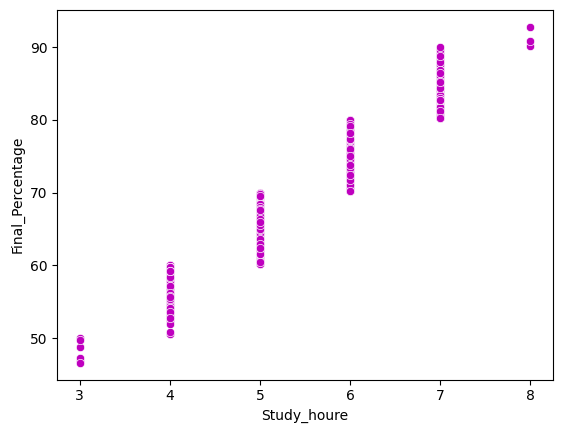

In [66]:
sns.scatterplot(x =df["Study_houre"],y= df["Final_Percentage"],c = "m")

C:\Users\sharn\AppData\Local\Temp\ipykernel_2360\1394522526.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x =df["Study_houre"],y= df["Final_Percentage"],palette="tab10")


<Axes: xlabel='Study_houre', ylabel='Final_Percentage'>

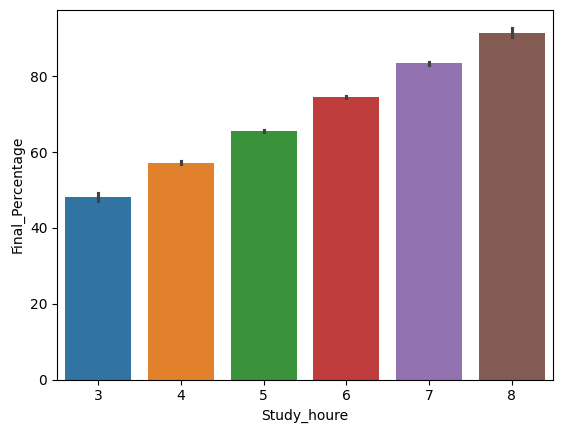

In [67]:
sns.barplot(x =df["Study_houre"],y= df["Final_Percentage"],palette="tab10")

In [68]:
df["Study_houre"].value_counts()

Study_houre
5    592
6    582
7    173
4    144
3      6
8      3
Name: count, dtype: int64

C:\Users\sharn\AppData\Local\Temp\ipykernel_2360\1118504896.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax =sns.countplot(x =df["Study_houre"],palette="tab10")


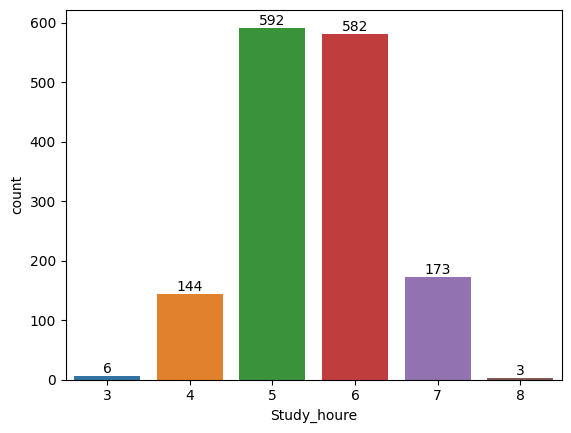

In [69]:
ax =sns.countplot(x =df["Study_houre"],palette="tab10")
val(ax)


C:\Users\sharn\AppData\Local\Temp\ipykernel_2360\3211528274.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  image =sns.countplot(x=df["Age"],palette="rocket")


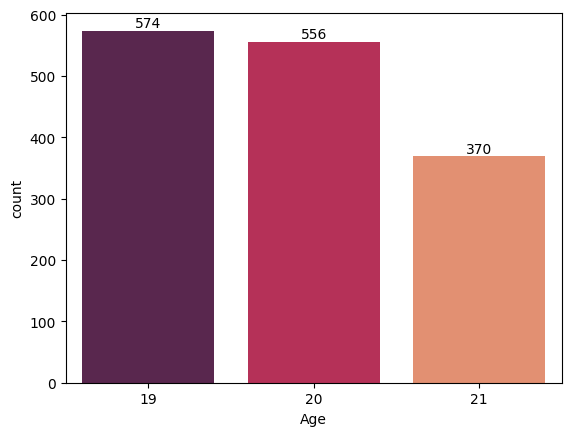

In [70]:
image =sns.countplot(x=df["Age"],palette="rocket")
val(image)

C:\Users\sharn\AppData\Local\Temp\ipykernel_2360\3000353729.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a  =sns.countplot(x =df["Attandance"],palette="viridis")


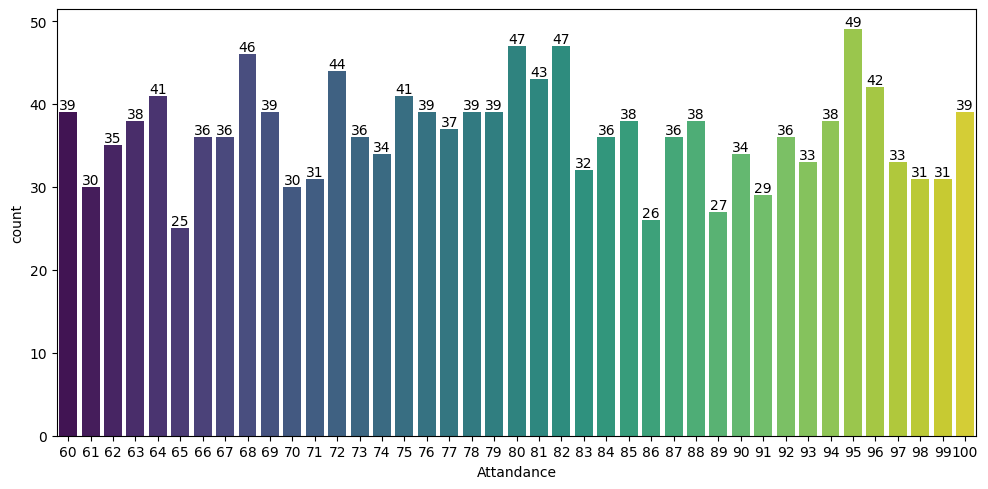

In [30]:
plt.figure(figsize=(10,5))
a  =sns.countplot(x =df["Attandance"],palette="viridis")
plt.tight_layout()
val(a)

In [33]:
sub1 = df.columns[5] 
sub1

'Attandance'

In [33]:
df.columns

Index(['Roll_No', 'Name', 'Gender', 'Semester', 'Branch', 'Attandance',
       'Maths', 'DS', 'OS', 'DBMS', 'AI', 'Study_houre', 'Final_Percentage',
       'Performance_Label', 'Father_Name', 'Mother_Name', 'Blood_Group',
       'Date_of_Birth', 'Age', 'City', 'Address', 'Pincode', 'State',
       'Country', 'Participant', 'Mobile_Number', 'Email_ID', 'Game'],
      dtype='str')

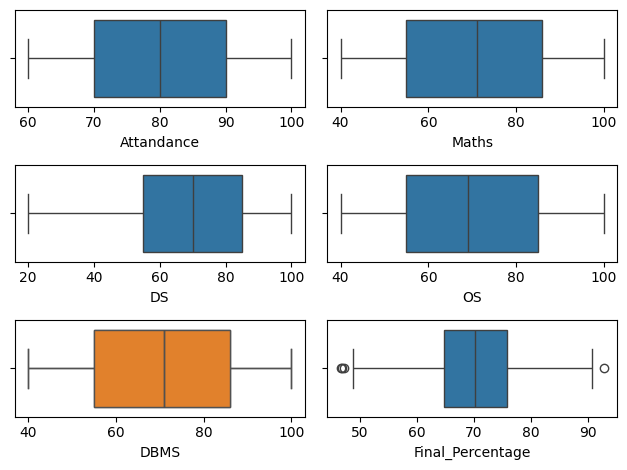

In [71]:
plt.subplot(3,2,1)
sns.boxplot(data=df,x="Attandance")
plt.subplot(3,2,2)
sns.boxplot(data=df,x="Maths")
plt.subplot(3,2,3)
sns.boxplot(data=df,x="DS")
plt.subplot(3,2,4)
sns.boxplot(data=df,x="OS")
plt.subplot(3,2,5)
sns.boxplot(data=df,x="DBMS")
plt.subplot(3,2,5)
sns.boxplot(data=df,x="AI")
plt.subplot(3,2,6)
sns.boxplot(data=df,x="Final_Percentage")
plt.tight_layout()

In [72]:
df.columns

Index(['Roll_No', 'Name', 'Gender', 'Semester', 'Branch', 'Attandance',
       'Maths', 'DS', 'OS', 'DBMS', 'AI', 'Study_houre', 'Final_Percentage',
       'Performance_Label', 'Father_Name', 'Mother_Name', 'Blood_Group',
       'Date_of_Birth', 'Age', 'City', 'Address', 'Pincode', 'State',
       'Country', 'Participant', 'Mobile_Number', 'Email_ID', 'Game'],
      dtype='str')

In [180]:
feature = ["Attandance","Maths","DS","OS","DBMS","AI","Study_houre","Performance_Label","Gender","Branch","Age","Final_Percentage"]

In [182]:
student = df[feature]
student.head()

,Attandance,Maths,DS,OS,DBMS,AI,Study_houre,Performance_Label,Gender,Branch,Age,Final_Percentage
0,71,95,59,93,100,78,7,Excellent,Female,AIML,19,85.0
1,70,78,95,85,49,60,6,Average,Male,AIDS,21,73.4
2,92,71,94,59,72,49,5,Average,Male,CSIT,21,69.0
3,75,67,99,41,74,50,5,Average,Male,CSE,19,66.2
4,80,97,51,90,88,96,7,Excellent,Female,DS,21,84.4


In [140]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cols  = ["Performance_Label","Gender","Branch"]
for col in cols:
    student[col] = le.fit_transform(student[col])

In [141]:
student.head()

,Attandance,Maths,DS,OS,DBMS,AI,Study_houre,Performance_Label,Gender,Branch,Age,Final_Percentage
0,71,95,59,93,100,78,7,1,0,1,19,85.0
1,70,78,95,85,49,60,6,0,1,0,21,73.4
2,92,71,94,59,72,49,5,0,1,3,21,69.0
3,75,67,99,41,74,50,5,0,1,2,19,66.2
4,80,97,51,90,88,96,7,1,0,4,21,84.4


In [142]:
X = student.drop("Performance_Label",axis =1)
y =  student["Performance_Label"]

In [143]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.20,random_state=42
)

In [148]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test =  scaler.fit_transform(X_test)

In [149]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

In [151]:
logis = LogisticRegression(max_iter=1000)
logis.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [152]:
y_pre = logis.predict(X_test)

In [157]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

print("Accuracy: ", accuracy_score(y_test, y_pre))
print("CM: \n", confusion_matrix(y_test, y_pre))

print("Precision: ", precision_score(y_test, y_pre, average='weighted'))
print("F1 Score: ", f1_score(y_test, y_pre, average='weighted'))
print("Recall Score: ", recall_score(y_test, y_pre, average='weighted'))

Accuracy:  0.9933333333333333
CM: 
 [[183   1   1]
 [  0  80   0]
 [  0   0  35]]
Precision:  0.9934670781893005
F1 Score:  0.9933490435365818
Recall Score:  0.9933333333333333


In [179]:
y_pre = logis.predict(X_train)
print("Accuracy: ", accuracy_score(y_train, y_pre))
print("CM: \n", confusion_matrix(y_train, y_pre))

Accuracy:  0.9891666666666666
CM: 
 [[736   1   7]
 [  5 344   0]
 [  0   0 107]]


In [162]:
neibors = [3,5,7,9]
for n in neibors: 
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train,y_train)
    y_pre = knn.predict(X_test)
    print(f"For neibors {n}")
    print("Accuracy: ", accuracy_score(y_test, y_pre))
    print("CM: \n", confusion_matrix(y_test, y_pre))
    

For neibors 3
Accuracy:  0.9
CM: 
 [[172  13   0]
 [ 12  68   0]
 [  5   0  30]]
For neibors 5
Accuracy:  0.8966666666666666
CM: 
 [[173  12   0]
 [  8  72   0]
 [ 11   0  24]]
For neibors 7
Accuracy:  0.8833333333333333
CM: 
 [[171  14   0]
 [  9  71   0]
 [ 12   0  23]]
For neibors 9
Accuracy:  0.9066666666666666
CM: 
 [[178   7   0]
 [  8  72   0]
 [ 13   0  22]]


In [176]:
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train,y_train)
y_pre = knn.predict(X_test)
print("Accuracy_testing: ", accuracy_score(y_test, y_pre))
print("CM_testing: \n", confusion_matrix(y_test, y_pre))


Accuracy_testing:  0.9066666666666666
CM_testing: 
 [[178   7   0]
 [  8  72   0]
 [ 13   0  22]]


In [178]:
y_pre = knn.predict(X_train)
print("Accuracy_training: ", accuracy_score(y_train, y_pre))
print("CM_training: \n", confusion_matrix(y_train, y_pre))

Accuracy_training:  0.9275
CM_training: 
 [[717  26   1]
 [ 38 311   0]
 [ 22   0  85]]


In [164]:
bays = GaussianNB()
bays.fit(X_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [165]:
y_pre = bays.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pre))
print("CM: \n", confusion_matrix(y_test, y_pre))

Accuracy:  0.96
CM: 
 [[173  11   1]
 [  0  80   0]
 [  0   0  35]]


In [173]:
y_pre = bays.predict(X_train)
print("Accuracy: ", accuracy_score(y_train, y_pre))
print("CM: \n", confusion_matrix(y_train, y_pre))

Accuracy:  0.9808333333333333
CM: 
 [[721  16   7]
 [  0 349   0]
 [  0   0 107]]


In [170]:
tree = DecisionTreeClassifier(max_depth=7)
tree.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [ ]:
y_pre = tree.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pre))
print("CM: \n", confusion_matrix(y_test, y_pre))

Accuracy:  0.98
CM: 
 [[184   1   0]
 [  0  80   0]
 [  5   0  30]]


In [172]:
y_pre = tree.predict(X_train)
print("Accuracy: ", accuracy_score(y_train, y_pre))
print("CM: \n", confusion_matrix(y_train, y_pre))

Accuracy:  1.0
CM: 
 [[744   0   0]
 [  0 349   0]
 [  0   0 107]]


In [206]:
feature = ["Attandance","Maths","DS","OS","DBMS","AI","Study_houre","Performance_Label","Gender","Branch","Age","Final_Percentage"]
student = df[feature]
student.head()

,Attandance,Maths,DS,OS,DBMS,AI,Study_houre,Performance_Label,Gender,Branch,Age,Final_Percentage
0,71,95,59,93,100,78,7,Excellent,Female,AIML,19,85.0
1,70,78,95,85,49,60,6,Average,Male,AIDS,21,73.4
2,92,71,94,59,72,49,5,Average,Male,CSIT,21,69.0
3,75,67,99,41,74,50,5,Average,Male,CSE,19,66.2
4,80,97,51,90,88,96,7,Excellent,Female,DS,21,84.4


In [207]:
le1 = LabelEncoder()

student["Performance_Label"] = le1.fit_transform(student["Performance_Label"])

In [208]:
from sklearn.preprocessing import OneHotEncoder

cols = ["Gender", "Branch"]

ohe1 = OneHotEncoder(sparse_output=False)

encoded = ohe1.fit_transform(student[cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe1.get_feature_names_out(cols)
)

student = pd.concat([student.drop(cols, axis=1), encoded_df], axis=1)

In [209]:
student.head()

,Attandance,Maths,DS,OS,DBMS,AI,Study_houre,Performance_Label,Age,Final_Percentage,Gender_Female,Gender_Male,Branch_AIDS,Branch_AIML,Branch_CSE,Branch_CSIT,Branch_DS
0,71,95,59,93,100,78,7,1,19,85.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,70,78,95,85,49,60,6,0,21,73.4,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,92,71,94,59,72,49,5,0,21,69.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,75,67,99,41,74,50,5,0,19,66.2,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,80,97,51,90,88,96,7,1,21,84.4,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [210]:
X = student.drop("Performance_Label",axis=1)
y = student["Performance_Label"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.20,random_state=42
)


In [211]:
scaler1 = StandardScaler()
X_train = scaler1.fit_transform(X_train)
X_test = scaler1.transform(X_test)

In [212]:
logistic = LogisticRegression(max_iter=1000)
logistic.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [213]:
y_pre = logistic.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pre))
print("CM: \n", confusion_matrix(y_test, y_pre))

print("Precision: ", precision_score(y_test, y_pre, average='weighted'))
print("F1 Score: ", f1_score(y_test, y_pre, average='weighted'))
print("Recall Score: ", recall_score(y_test, y_pre, average='weighted'))

Accuracy:  0.9966666666666667
CM: 
 [[184   0   1]
 [  0  80   0]
 [  0   0  35]]
Precision:  0.9967592592592592
F1 Score:  0.9966856241332368
Recall Score:  0.9966666666666667


In [214]:
y_pre = logistic.predict(X_train)
print("Accuracy: ", accuracy_score(y_train, y_pre))
print("CM: \n", confusion_matrix(y_train, y_pre))

Accuracy:  0.99
CM: 
 [[736   1   7]
 [  4 345   0]
 [  0   0 107]]


In [215]:
neibors = [3,5,7,9]
for n in neibors: 
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train,y_train)
    y_pre = knn.predict(X_test)
    print(f"For neibors {n}")
    print("Accuracy: ", accuracy_score(y_test, y_pre))
    print("CM: \n", confusion_matrix(y_test, y_pre))
    

For neibors 3
Accuracy:  0.86
CM: 
 [[170  14   1]
 [ 16  64   0]
 [ 11   0  24]]
For neibors 5
Accuracy:  0.83
CM: 
 [[173  12   0]
 [ 18  62   0]
 [ 21   0  14]]
For neibors 7
Accuracy:  0.8233333333333334
CM: 
 [[175  10   0]
 [ 22  58   0]
 [ 21   0  14]]
For neibors 9
Accuracy:  0.8533333333333334
CM: 
 [[175  10   0]
 [ 16  64   0]
 [ 18   0  17]]


In [216]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)
y_pre = knn.predict(X_test)
print("Accuracy_testing: ", accuracy_score(y_test, y_pre))
print("CM_testing: \n", confusion_matrix(y_test, y_pre))

Accuracy_testing:  0.86
CM_testing: 
 [[170  14   1]
 [ 16  64   0]
 [ 11   0  24]]


In [217]:
y_pre = knn.predict(X_train)
print("Accuracy_training: ", accuracy_score(y_train, y_pre))
print("CM_training: \n", confusion_matrix(y_train, y_pre))

Accuracy_training:  0.9391666666666667
CM_training: 
 [[716  28   0]
 [ 33 316   0]
 [ 12   0  95]]


In [218]:
bays = GaussianNB()
bays.fit(X_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [219]:
y_pre = bays.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pre))
print("CM: \n", confusion_matrix(y_test, y_pre))

Accuracy:  0.99
CM: 
 [[182   2   1]
 [  0  80   0]
 [  0   0  35]]


In [220]:
y_pre = bays.predict(X_train)
print("Accuracy: ", accuracy_score(y_train, y_pre))
print("CM: \n", confusion_matrix(y_train, y_pre))

Accuracy:  0.9783333333333334
CM: 
 [[719  18   7]
 [  1 348   0]
 [  0   0 107]]


In [221]:
tree = DecisionTreeClassifier(max_depth=7)
tree.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [222]:
y_pre = tree.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, y_pre))
print("CM: \n", confusion_matrix(y_test, y_pre))

Accuracy:  1.0
CM: 
 [[185   0   0]
 [  0  80   0]
 [  0   0  35]]


In [223]:
y_pre = tree.predict(X_train)
print("Accuracy: ", accuracy_score(y_train, y_pre))
print("CM: \n", confusion_matrix(y_train, y_pre))

Accuracy:  1.0
CM: 
 [[744   0   0]
 [  0 349   0]
 [  0   0 107]]


In [225]:
pickle.dump(le1,open("LabelEncoder.pkl","wb"))
pickle.dump(ohe1,open("OneHotEncoder.pkl","wb"))
pickle.dump(scaler1,open("Scaler.pkl","wb"))
pickle.dump(logistic,open("Log_model.pkl","wb"))

In [226]:
X.columns

Index(['Attandance', 'Maths', 'DS', 'OS', 'DBMS', 'AI', 'Study_houre', 'Age',
       'Final_Percentage', 'Gender_Female', 'Gender_Male', 'Branch_AIDS',
       'Branch_AIML', 'Branch_CSE', 'Branch_CSIT', 'Branch_DS'],
      dtype='str')